In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
indian_banking_stocks = {
    'HDFCBANK.NS': 'HDFC Bank Limited',
    'ICICIBANK.NS': 'ICICI Bank Limited',
    'SBIN.NS':'State Bank of India',
    'KOTAKBANK.NS':'Kotak Mahindra Bank',
    'AXISBANK.NS': 'Axis Bank Limited',
    'INDUSINDBK.NS':'IndusInd Bank Limited',
    'FEDERALBNK.NS': 'Federal Bank Limited',
    'BANDHANBANK.NS': 'Bandhan Bank Limited',
    'IDFCIRSTB.NS': 'IDFC First Bank Limited',
     'PNB.NS': 'Punjab National Bank'
}

In [4]:
end_date = datetime.now()
start_date = end_date- timedelta(days=730)
# downloading the historical data for the past two years

In [5]:
# get the data for all indian banking stocks
stock_data = {}
for ticker in indian_banking_stocks.keys():
    try: 
        stock_data[ticker] = yf.download(ticker, start=start_date, end=end_date)
        print(f"Download data for {ticker}")
    except Exception as e:
        print(f"failed to download {ticker}:{e}")

[*********************100%***********************]  1 of 1 completed


Download data for HDFCBANK.NS


[*********************100%***********************]  1 of 1 completed


Download data for ICICIBANK.NS


[*********************100%***********************]  1 of 1 completed


...

Download data for BANDHANBANK.NS


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: IDFCIRSTB.NS"}}}
$IDFCIRSTB.NS: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['IDFCIRSTB.NS']: possibly delisted; no timezone found


Download data for IDFCIRSTB.NS


[*********************100%***********************]  1 of 1 completed

Download data for PNB.NS


In [6]:
closing_prices = pd.DataFrame()
for ticker in stock_data.keys():
    if not stock_data[ticker].empty:
      closing_prices[ticker.replace('.NS',' ')] = stock_data[ticker]['Close']

In [7]:
#calculation of return and other metrics
returns = closing_prices.pct_change().dropna()
cumulative_returns = (1 +returns).cumprod()


In [8]:
print("stock performance analysis")

stock performance analysis


In [9]:
#calculate performance metrics
performance_metrics = pd.DataFrame()
performance_metrics['Total Return(%)'] = ((cumulative_returns.iloc[-1] -1) * 100).round(2)
performance_metrics['Annualized returns'] = (((cumulative_returns.iloc[-1]) ** (252/len(returns)) -1)*100).round(2)
performance_metrics['volatility(%)'] = (returns.std() * np.sqrt(252) * 100).round(2)
performance_metrics['Sharpe Ratio'] = (performance_metrics['Annualized returns'] / performance_metrics['volatility(%)']).round(2)
performance_metrics['Max Drawdown (%)'] = ((cumulative_returns / cumulative_returns.expanding().max() -1).min() *100).round(2) 
print("performance summary:")
print(performance_metrics.sort_values('Total Return(%)', ascending=False))

performance summary:
             Total Return(%)  Annualized returns  volatility(%)  Sharpe Ratio  \
FEDERALBNK             79.65               34.51          25.62          1.35   
SBIN                   21.37               10.30          22.44          0.46   
ICICIBANK              17.41                8.46          18.58          0.46   
KOTAKBANK               7.16                3.56          22.33          0.16   
HDFCBANK                4.58                2.29          19.35          0.12   
AXISBANK                1.62                0.82          23.17          0.04   
PNB                    -5.76               -2.96          28.92         -0.10   
INDUSINDBK            -29.38              -16.14          36.83         -0.44   

             Max Drawdown (%)  
FEDERALBNK             -18.07  
SBIN                   -22.55  
ICICIBANK              -18.37  
KOTAKBANK              -22.03  
HDFCBANK               -27.78  
AXISBANK               -26.64  
PNB                    -3

In [10]:
#risk analysis
print("RISK ANALYSIS")
correlation_matrix = returns.corr()
print(f"\n Average Correlation: {correlation_matrix.mean().mean():.3f}")

RISK ANALYSIS

 Average Correlation: 0.464


In [11]:
#valuation at risk corrrelation
var_95 = returns.quantile(0.05) * 100
print(f"\n95%value at risk (Daily)")
for stock in var_95.index:
    print(f"{stock}: var_95[stock]:.2f%")


95%value at risk (Daily)
HDFCBANK : var_95[stock]:.2f%
ICICIBANK : var_95[stock]:.2f%
SBIN : var_95[stock]:.2f%
KOTAKBANK : var_95[stock]:.2f%
AXISBANK : var_95[stock]:.2f%
INDUSINDBK : var_95[stock]:.2f%
FEDERALBNK : var_95[stock]:.2f%
PNB : var_95[stock]:.2f%


In [12]:
#visualization
plt.style.use('seaborn-v0_8')
fig = plt.figure(figsize = (20,15))

<Figure size 2000x1500 with 0 Axes>

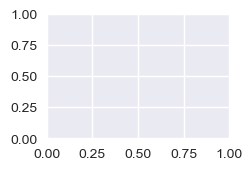

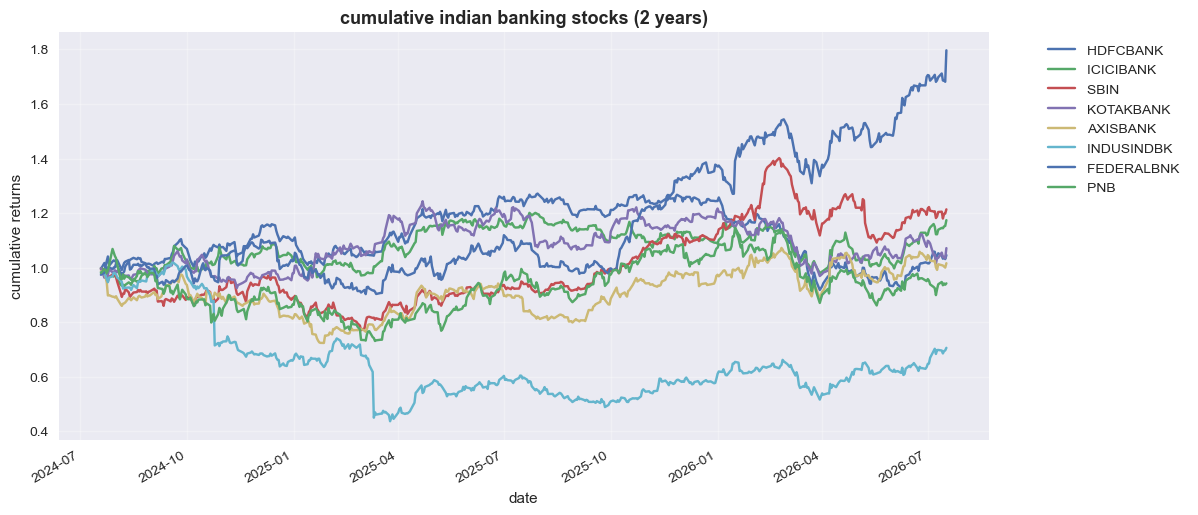

In [13]:
plt.subplot(3,3,1)
cumulative_returns.plot(figsize = (12,6))
plt.title('cumulative indian banking stocks (2 years)', fontsize = 13, fontweight='bold')
plt.xlabel('date')
plt.ylabel('cumulative returns')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, alpha=0.3)

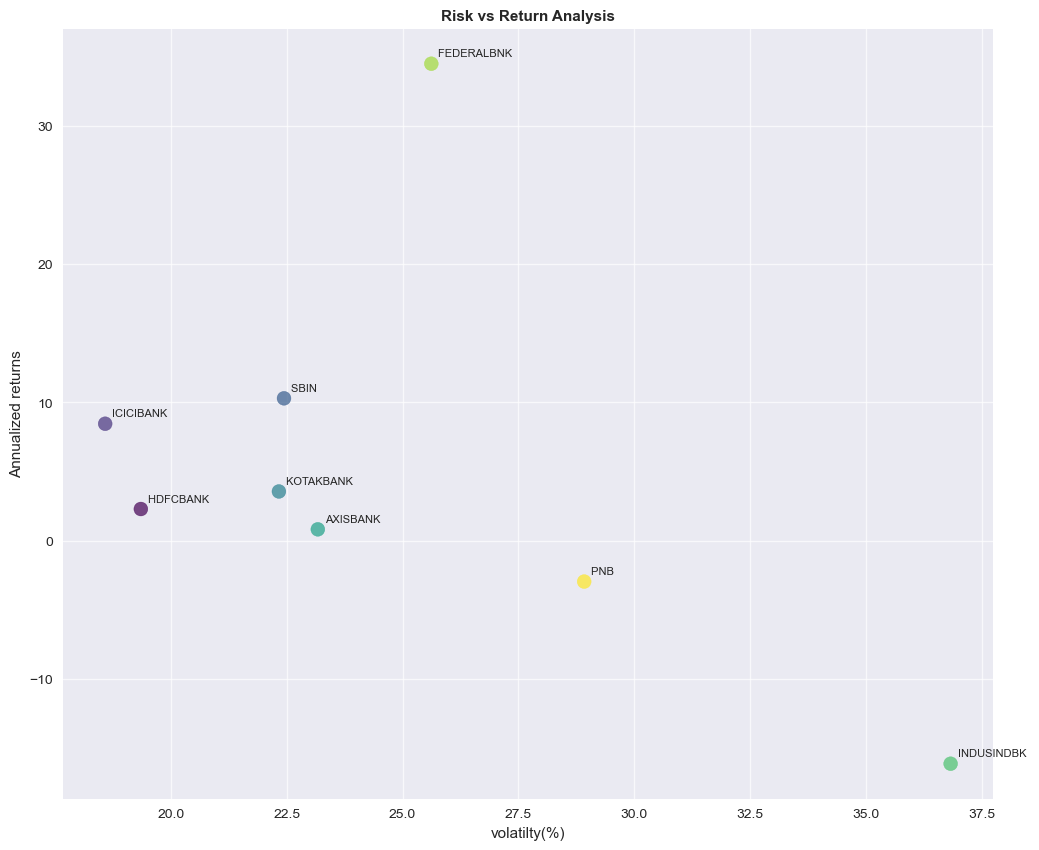

In [27]:
plt.figure(figsize=(12,10))
plt.scatter(performance_metrics['volatility(%)'], performance_metrics['Annualized returns'],
           s=100, alpha=0.7, c=range(len(performance_metrics)),cmap='viridis')  


for i, stock in enumerate(performance_metrics.index):
    
    plt.annotate(stock, (performance_metrics['volatility(%)'].iloc[i],
                  performance_metrics['Annualized returns'].iloc[i]),
                  xytext=(5,5), textcoords='offset points', fontsize=8)

plt.xlabel('volatilty(%)')
plt.ylabel('Annualized returns')
plt.title('Risk vs Return Analysis', fontsize = 11, fontweight = 'bold')
plt.grid(True, alpha=0.7)

Text(0.5, 1.0, 'stock correlation matrix')

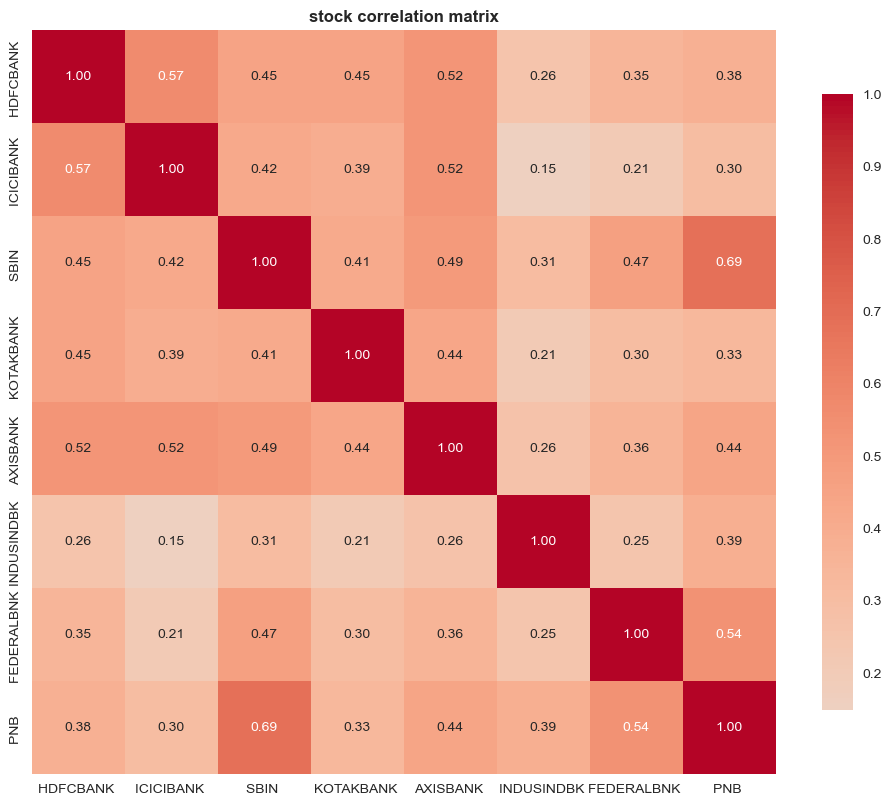

In [29]:

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap = 'coolwarm', center=0, square= True, fmt='.2f',cbar_kws={'shrink':0.8})
plt.title('stock correlation matrix', fontsize=12, fontweight = 'bold')           

(array([1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(1, 0, 'HDFCBANK '),
  Text(2, 0, 'ICICIBANK '),
  Text(3, 0, 'SBIN '),
  Text(4, 0, 'KOTAKBANK '),
  Text(5, 0, 'AXISBANK '),
  Text(6, 0, 'INDUSINDBK '),
  Text(7, 0, 'FEDERALBNK '),
  Text(8, 0, 'PNB ')])

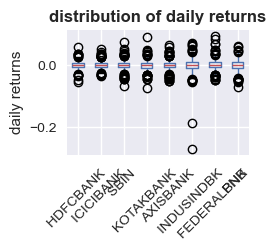

In [41]:
plt.subplot(3,3,4)
returns.boxplot(figsize=(20,18), rot=45)
plt.title('distribution of daily returns', fontsize=12, fontweight='bold')
plt.ylabel('daily returns')
plt.xticks(rotation=45)

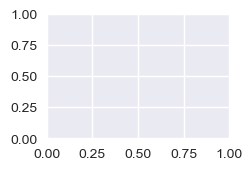

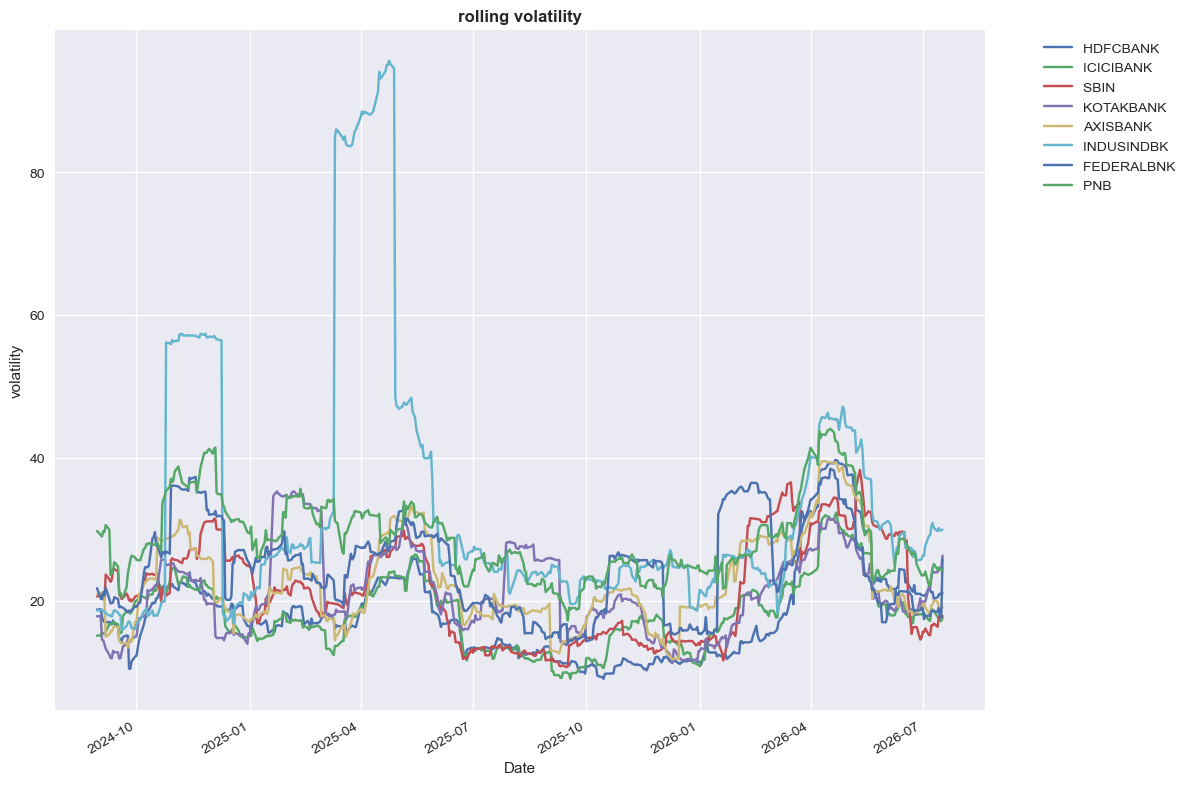

In [45]:
# rolling volatility
plt.subplot(3,3,5)
rol_vol = returns.rolling(window=30).std() * np.sqrt(252) * 100
rol_vol.plot(figsize=(12,10))
plt.title('rolling volatility', fontsize=12, fontweight='bold')
plt.ylabel('volatility')
plt.legend(bbox_to_anchor =(1.05,1), loc='upper left')

Text(0.5, 0, 'total returns')

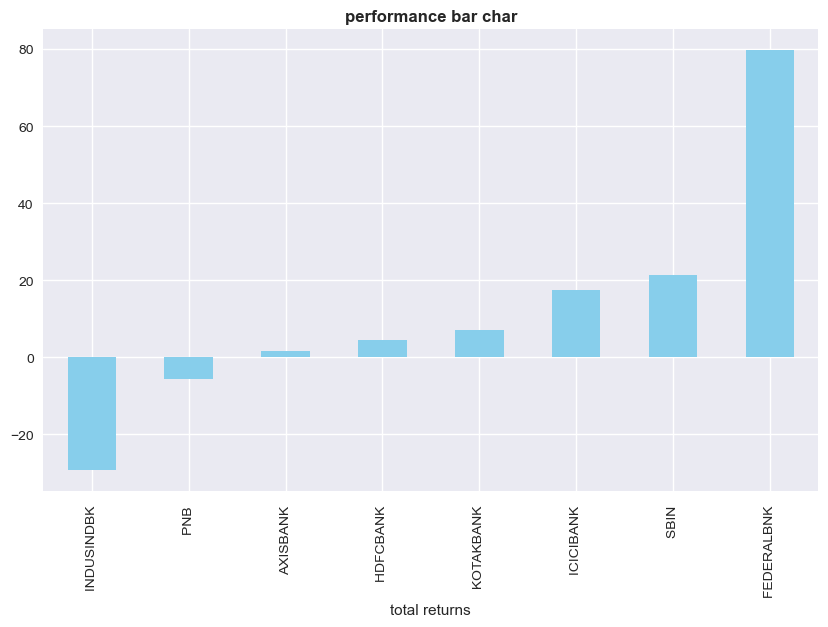

In [51]:
# performance bar chart
plt.figure(figsize=(12,10))
performance_metrics['Total Return(%)'].sort_values(ascending = True).plot(kind='bar', color='skyblue', figsize=(10,6))
plt.title('performance bar char', fontsize=12, fontweight='bold')
plt.xlabel('total returns')

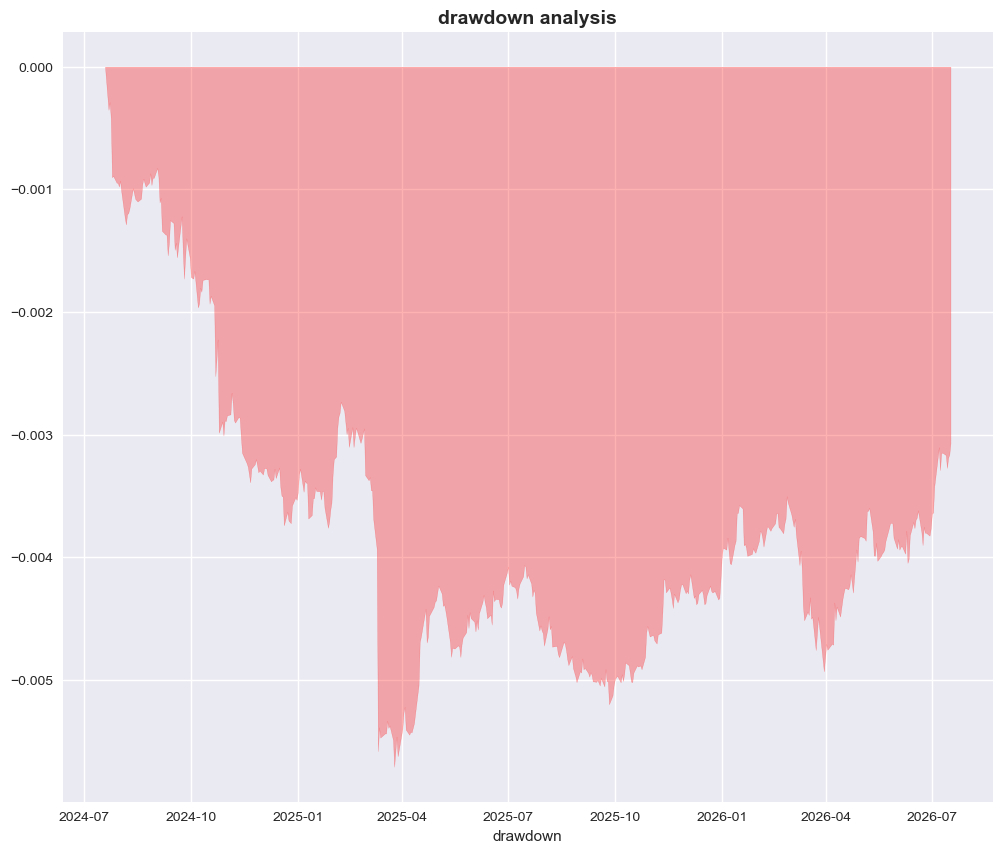

In [67]:
# drawdown analysis
plt.figure(figsize =(12,10))
drawdown = (cumulative_returns/cumulative_returns.expanding().max() - 1)/100
plt.title('drawdown analysis', fontsize=14, fontweight='bold')
plt.xlabel('drawdown')
plt.fill_between(drawdown.index, drawdown.min(axis=1), 0, alpha=0.3, color='red')

Text(0.5, 1.0, 'Monthly Returns - FEDERALBNK ')

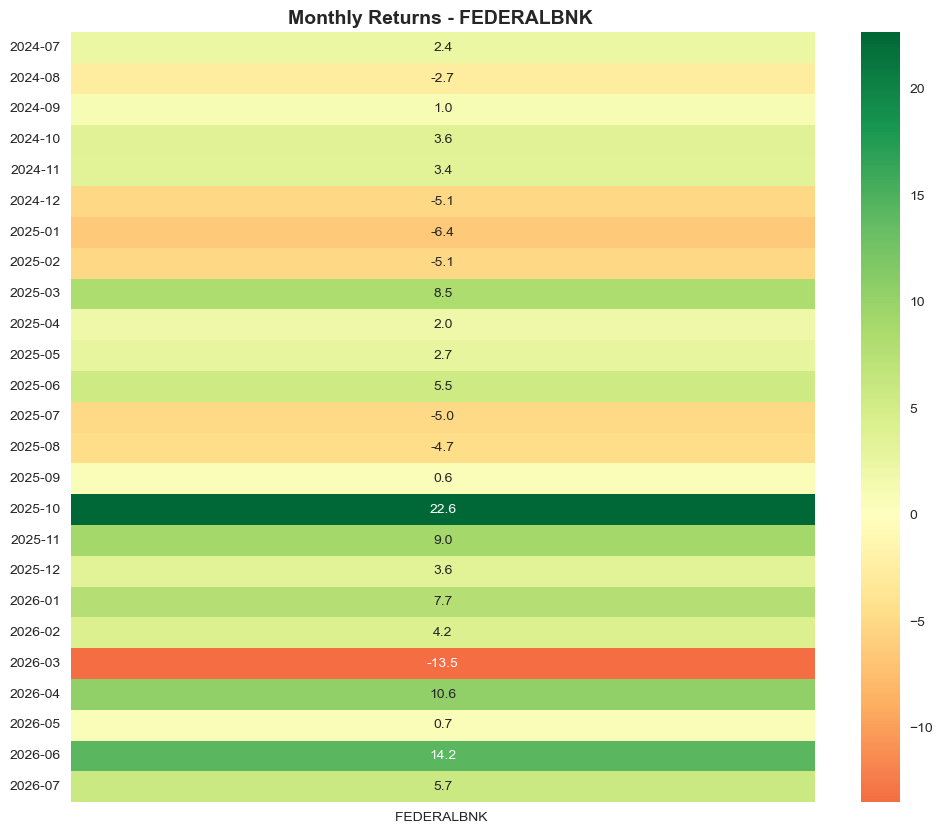

In [70]:
plt.figure(figsize=(12,10))
best_stock = performance_metrics['Total Return(%)'].idxmax()
monthly_returns = returns[best_stock].resample('M').apply(lambda x: (1+x).prod() -1) *100
monthly_returns.index =  monthly_returns.index.strftime('%Y-%m')
monthly_data = monthly_returns.values.reshape(-1, 1)
sns.heatmap(monthly_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
           yticklabels=monthly_returns.index, xticklabels=[best_stock])
plt.title(f'Monthly Returns - {best_stock}', fontsize=14, fontweight='bold')

In [74]:
print("\n=== INVESTMENT INSIGHTS ===")
best_performer = performance_metrics['Total Return(%)'].idxmax()
worst_performer = performance_metrics['Total Return(%)'].idxmin()
lowest_risk = performance_metrics['volatility(%)'].idxmin()
highest_sharpe = performance_metrics['Sharpe Ratio'].idxmax()
print(f" Best Performer: {best_performer} ({performance_metrics.loc[best_performer, 'Total Return(%)']:.2f}%)")
print(f" Worst Performer: {worst_performer} ({performance_metrics.loc[worst_performer, 'Total Return(%)']:.2f}%)")
print(f" Lowest Risk: {lowest_risk} ({performance_metrics.loc[lowest_risk, 'volatility(%)']:.2f}%)")
print(f" Best Risk-Adjusted Return: {highest_sharpe} ({performance_metrics.loc[highest_sharpe, 'Sharpe Ratio']:.2f}%)")


=== INVESTMENT INSIGHTS ===
 Best Performer: FEDERALBNK  (79.65%)
 Worst Performer: INDUSINDBK  (-29.38%)
 Lowest Risk: ICICIBANK  (18.58%)
 Best Risk-Adjusted Return: FEDERALBNK  (1.35%)
